## Validating ADM Energy from PN Binding Energy against NR

This notebook validates the initial ADM mass estimated by `gw_remnant`'s built-in
PN binding-energy expressions against the exact ADM energy from SXS NR metadata.

For a binary at large separation, $M_{\rm ADM} = M_{\rm initial} + E_{\rm binding}^{\rm PN}$
where $E_{\rm binding}^{\rm PN} < 0$. We compare this PN estimate against the NR value
$M_{\rm ADM}^{\rm NR}$ across 38 non-precessing, non-eccentric SXS simulations spanning
$q \in [1, 15]$ and $\chi_{1z} \in [-0.9, 0.8]$.

Requires `pip install gw_remnant[nr]`.

Contact: Tousif Islam [tousifislam24@gmail.com]

### 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import sxs

from gw_remnant.gw_remnant_calculator import GWRemnantCalculator

lal.MSUN_SI != Msun


### 2. Load SXS simulations

Select non-precessing, non-eccentric simulations with $\geq 25$ orbits,
where the primary has $|\chi_{1z}| \geq 0.05$ and the secondary is non-spinning.

In [2]:
LMAX = 4

def load_sxs_simulation(simulation_id):
    """Load an SXS simulation and return (time, h_dict, q, chi1z)."""
    sim = sxs.load(simulation_id)
    md = sim.metadata
    h = sim.h

    reference_time = md.get("reference_time", h.t[0])
    h = h[h.index_closest_to(reference_time):]
    t = np.array(h.t, float)

    h_dict = {}
    for l in range(2, LMAX + 1):
        for m in range(-l, l + 1):
            h_dict[(l, m)] = np.array(h.data[:, h.index(l, m)], complex)

    q = float(md.reference_mass_ratio)
    chi1 = np.array(md.initial_dimensionless_spin1, float)
    chi1z = float(chi1[2])

    T0 = t[np.argmax(np.abs(h_dict[(2, 2)]))]
    t = t - T0

    return t, h_dict, q, chi1z

In [3]:
df_full = sxs.load("dataframe", tag="3.0.0")
df = df_full.undeprecated.BBH.nonprecessing.noneccentric

mask = (
    (df['number_of_orbits_from_reference_time'] >= 25)
    & (abs(df['initial_dimensionless_spin2_mag']) <= 0.01)
    & (abs(df['initial_dimensionless_spin1_mag']) >= 0.05)
)
simulations = list(df[mask].index)
qvals = np.round(np.array(df[mask]['reference_mass_ratio']), 3)
s1vals = np.array(df[mask]['initial_dimensionless_spin1_z'])
Madm_nr = np.array(df[mask]['initial_ADM_energy'])

print(f"Selected {len(simulations)} simulations")
print(f"q range: [{qvals.min():.1f}, {qvals.max():.1f}]")
print(f"chi1z range: [{s1vals.min():.2f}, {s1vals.max():.2f}]")

Selected 38 simulations
q range: [1.0, 15.0]
chi1z range: [-0.90, 0.80]


### 3. Compute ADM energy from PN binding energy

For each simulation, load the NR waveform and compute the PN binding energy
via `GWRemnantCalculator`. The estimated ADM mass is $M_{\rm ADM} = 1 + E_{\rm binding}^{\rm PN}$.

In [4]:
Madm_approx = []

for i in range(len(simulations)):
    t, h_dict, q, chi1z = load_sxs_simulation(simulations[i])
    print(f"[{i+1}/{len(simulations)}] {simulations[i]}:  q={q:.2f},  chi1z={chi1z:.3f},  t0={t[0]:.1f} M")

    calc = GWRemnantCalculator(
        time=t, h_dict=h_dict, q=q,
        chi1=[0, 0, chi1z], chi2=[0, 0, 0],
    )
    Madm_approx.append(1.0 - float(calc.E_initial))

Madm_approx = np.array(Madm_approx)

[1/38] SXS:BBH:0202:  q=7.00,  chi1z=0.600,  t0=-17922.3 M


/var/folders/9k/xlxjfz4d2cz1063spty94p0r0000gq/T/ipykernel_25218/3778523358.py:7: UserWarning: Tips: If you are using NR waveforms, ensure that they do not contain junk radiation, as that is known to corrupt the remnant property estimation.
  calc = GWRemnantCalculator(


[2/38] SXS:BBH:0203:  q=7.00,  chi1z=0.400,  t0=-18134.0 M


[3/38] SXS:BBH:0204:  q=7.00,  chi1z=0.400,  t0=-34409.4 M


[4/38] SXS:BBH:0205:  q=7.00,  chi1z=-0.400,  t0=-13824.7 M


...

[34/38] SXS:BBH:4235:  q=10.00,  chi1z=-0.800,  t0=-8158.5 M


[35/38] SXS:BBH:4236:  q=12.00,  chi1z=0.500,  t0=-9727.2 M


[36/38] SXS:BBH:4260:  q=12.00,  chi1z=-0.500,  t0=-9550.1 M


[37/38] SXS:BBH:4261:  q=15.00,  chi1z=0.500,  t0=-9689.6 M


[38/38] SXS:BBH:4284:  q=15.00,  chi1z=-0.500,  t0=-9346.5 M


### 4. Comparison plots

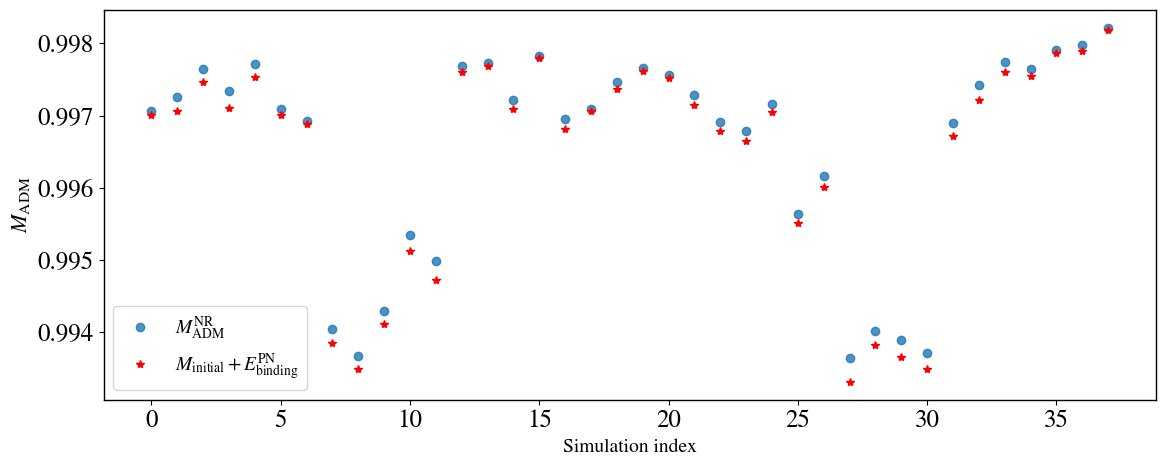

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(Madm_nr, 'o', c='C0', alpha=0.8, label='$M_{\\rm ADM}^{\\rm NR}$')
ax.plot(Madm_approx, '*', c='r', label='$M_{\\rm initial}+E_{\\rm binding}^{\\rm PN}$')
ax.legend(fontsize=14)
ax.set_ylabel('$M_{\\rm ADM}$', fontsize=16)
ax.set_xlabel('Simulation index', fontsize=14)
plt.tight_layout()
plt.show()

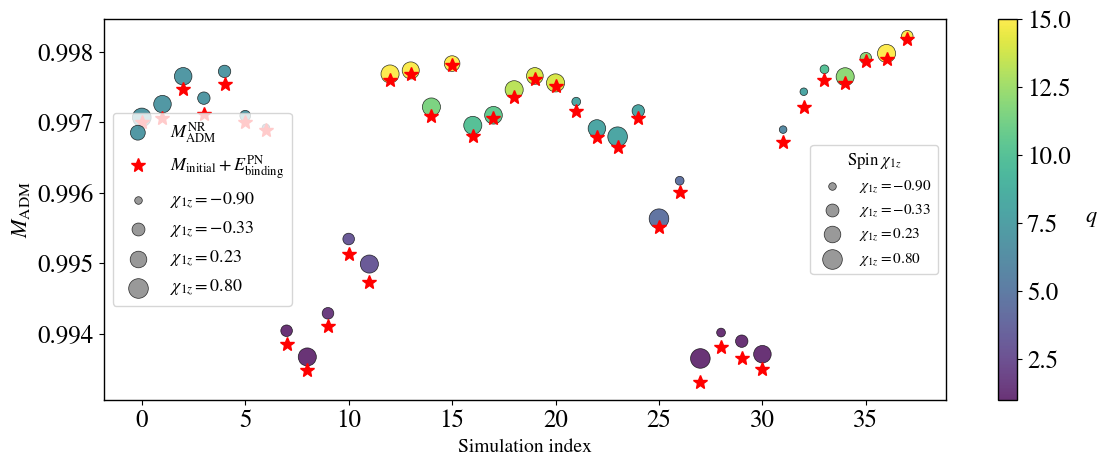

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

norm_q = Normalize(vmin=qvals.min(), vmax=qvals.max())
norm_s1 = Normalize(vmin=s1vals.min(), vmax=s1vals.max())
sizes = 30 + 170 * norm_s1(s1vals)

scatter = ax.scatter(
    range(len(Madm_nr)), Madm_nr,
    c=qvals, s=sizes, cmap='viridis', norm=norm_q,
    marker='o', alpha=0.8, edgecolors='black', linewidths=0.5,
    label='$M_{\\rm ADM}^{\\rm NR}$',
)
ax.plot(Madm_approx, '*', c='r', markersize=10,
        label='$M_{\\rm initial}+E_{\\rm binding}^{\\rm PN}$')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('$q$', fontsize=16, rotation=0, labelpad=15)

unique_s1 = np.linspace(s1vals.min(), s1vals.max(), 4)
legend_sizes = 30 + 170 * (unique_s1 - s1vals.min()) / (s1vals.max() - s1vals.min())
size_handles = [
    plt.scatter([], [], s=sz, c='gray', alpha=0.8, edgecolors='black', linewidths=0.5,
                label=f'$\\chi_{{1z}}={val:.2f}$')
    for sz, val in zip(legend_sizes, unique_s1)
]

leg1 = ax.legend(fontsize=13, loc='center left')
leg2 = ax.legend(handles=size_handles, title='Spin $\\chi_{1z}$',
                 fontsize=11, loc='center right', title_fontsize=12)
ax.add_artist(leg1)

ax.set_ylabel('$M_{\\rm ADM}$', fontsize=16)
ax.set_xlabel('Simulation index', fontsize=14)
plt.tight_layout()
plt.show()

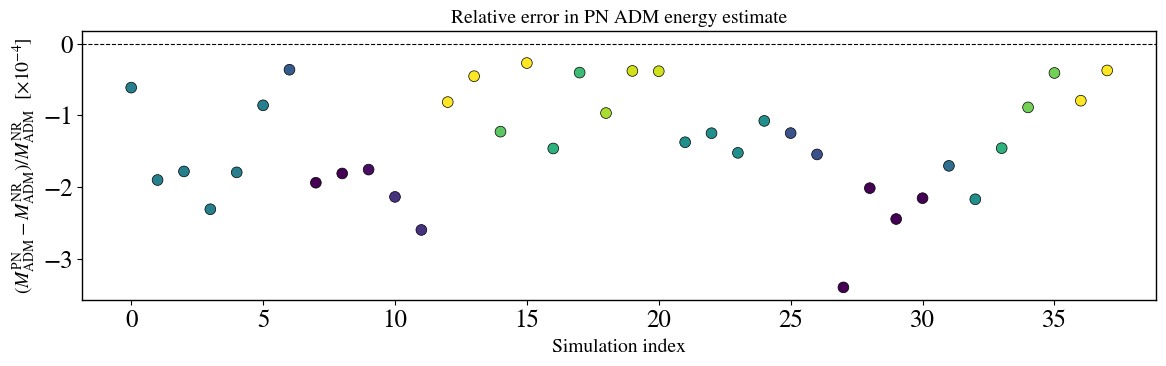

Max |relative error|: 3.39e-04
Mean |relative error|: 1.37e-04


In [7]:
residual = (Madm_approx - Madm_nr) / Madm_nr

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(range(len(residual)), residual * 1e4, c=qvals, cmap='viridis',
           norm=norm_q, edgecolors='black', linewidths=0.5, s=60)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_ylabel('$(M_{\\rm ADM}^{\\rm PN} - M_{\\rm ADM}^{\\rm NR})/M_{\\rm ADM}^{\\rm NR}$  [$\\times 10^{-4}$]',
              fontsize=14)
ax.set_xlabel('Simulation index', fontsize=14)
ax.set_title('Relative error in PN ADM energy estimate', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Max |relative error|: {np.max(np.abs(residual)):.2e}")
print(f"Mean |relative error|: {np.mean(np.abs(residual)):.2e}")